# AWG5208 + ATS9371 unified experiments

This notebook uses `AWGAlazar` as the hardware boundary.

Included experiments:

1. Connect and configure AWG5208 and ATS9371.
2. Upload a delayed Gaussian-square 50 MHz readout and aligned marker.
3. Acquire raw ADC records and one integrated IQ point.
4. Recover a time-resolved IQ waveform with moving-average demodulation.
5. Inspect individual shots for trigger jitter.
6. Sweep AWG carrier phase and inspect IQ rotation.
7. Capture 0 and 180 degree single-shot clouds.
8. Plot cumulative trajectories while integration time grows from zero.

Run the cells in order. Hardware acquisition cells start the AWG and wait for
external marker triggers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from awg_alazar import AWGAlazar
from awg5200 import delay, gaussian_square_ns, waveform

## Experiment parameters

In [7]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9
CARRIER_FREQUENCY_HZ = 50e6
ADC_CHANNEL = "CHB"  # "CHA"/0 or "CHB"/1

AWG_SIGNAL_CHANNEL = 3
AWG_MARKER_CHANNEL = 1
CHANNEL_AMPLITUDE_VPP = 0.5
MARKER_LOW_VOLTS = 0.0
MARKER_HIGH_VOLTS = 1.2

READOUT_START_NS = 1000
READOUT_DURATION_NS = 1000
EDGE_SIGMA_NS = 100
PULSE_PEAK_VOLTS = 0.02
AWG_TOTAL_DURATION_NS = 5000

# Alazar starts recording this long after the marker trigger.
TRIGGER_DELAY_NS = 0
NUM_AVERAGES = 1000
ACQUIRE_WINDOW_NS = 1200
INTEGRATE_WINDOW_NS = (100, 1100)
MOVING_AVERAGE_TIME_NS = 20
ALAZAR_TIMEOUT_MS = 60_000

# Set this only when the beginning of the record is known to contain no pulse.
# It removes ATS9371 odd/even ADC-core offsets from that baseline interval.
BASELINE_TIME_NS = None

## Connect and configure both instruments

In [8]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    tone_frequency_hz=CARRIER_FREQUENCY_HZ,
    trigger_delay_s=TRIGGER_DELAY_NS * 1e-9,
    acquire_window_ns=ACQUIRE_WINDOW_NS,
    integrate_window_ns=INTEGRATE_WINDOW_NS,
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=MOVING_AVERAGE_TIME_NS * 1e-9,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    baseline_time_s=(
        None if BASELINE_TIME_NS is None else BASELINE_TIME_NS * 1e-9
    ),
    use_external_10mhz_reference=True,
)

print("AWG:", experiment.awg.identify())
print("AWG 100 ns:", experiment.ns2cycles(100, inst="dac"), "cycles")
print("ADC 100 ns:", experiment.ns2cycles(100, inst="adc"), "cycles")
print("ATS trigger delay:", experiment.trigger_delay_samples, "samples")
print("ATS input channel:", experiment.adc_channel_name)
print("ATS acquire window:", experiment.acquire_window_cycles, "samples")
print("ATS integrate window:", experiment.integrate_window_cycles, "samples")

AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
AWG 100 ns: 250 cycles
ADC 100 ns: 100 cycles
ATS trigger delay: 0 samples
ATS input channel: CHB
ATS acquire window: 1280 samples
ATS integrate window: (100, 1100) samples


## Readout upload helper

The helper is intentionally small: it creates one envelope, places it on the
AWG timeline, uploads it, and creates a marker on channel 1 that follows the
active readout region on channel 3.

In [9]:
def upload_readout(
    phase_radians=0.0,
    peak_volts=PULSE_PEAK_VOLTS,
    name="readout",
):
    envelope = gaussian_square_ns(
        duration_ns=READOUT_DURATION_NS,
        sample_rate_hz=experiment.awg_sample_rate_hz,
        edge_sigma_ns=EDGE_SIGMA_NS,
        amplitude_volts=peak_volts,
    )
    readout = waveform(
        envelope,
        fc=experiment.tone_frequency_hz,
        ch=AWG_SIGNAL_CHANNEL,
        phase_radians=phase_radians,
        name=name,
    )
    timeline = delay(READOUT_START_NS * 1e-9) / readout
    names = experiment.awg.upload_timeline(
        timeline,
        amplitude_vpp={AWG_SIGNAL_CHANNEL: CHANNEL_AMPLITUDE_VPP},
        total_duration_s=AWG_TOTAL_DURATION_NS * 1e-9,
    )
    marker_name = experiment.awg.marker(
        waveform_ch=AWG_SIGNAL_CHANNEL,
        marker_ch=AWG_MARKER_CHANNEL,
        marker_number=1,
        low_volts=MARKER_LOW_VOLTS,
        high_volts=MARKER_HIGH_VOLTS,
        amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
    )
    return names, marker_name


names, marker_name = upload_readout()
print("Signal waveform:", names[AWG_SIGNAL_CHANNEL])
print("Marker waveform:", marker_name)
print("AWG error:", experiment.awg.error())

Signal waveform: readout
Marker waveform: marker_ch1_for_ch3
AWG error: 0,"No error"


## Raw acquisition and integrated IQ

`acquire()` performs one hardware acquisition. It returns:

- `iq`: one point averaged over the configured integration window and shots.
- `downconverted_iq`: full complex baseband data for every shot.

The matching ADC codes and voltage records remain available on the class.

In [10]:
iq, downconverted_iq = experiment.acquire(NUM_AVERAGES)

raw_codes = experiment.last_raw_codes
records_volts = experiment.last_records_volts
raw_time_ns = experiment.last_time_s * 1e9

print("Raw codes shape:", raw_codes.shape)
print("Voltage records shape:", records_volts.shape)
print("Downconverted shape:", downconverted_iq.shape)
print(f"Integrated IQ: I={iq.real * 1e3:.6f} mV, Q={iq.imag * 1e3:.6f} mV")
print("Capture diagnostics:")
for key, value in experiment.capture_diagnostics().items():
    print(f"  {key}: {value}")
print("AWG error:", experiment.awg.error())

Raw codes shape: (1000, 1280)
Voltage records shape: (1000, 1280)
Downconverted shape: (1000, 1280)
Integrated IQ: I=8.706305 mV, Q=1.667653 mV
Capture diagnostics:
  adc_channel: CHB
  adc_bits: 12
  adc_lsb_mv: 0.1953125
  raw_code_min: 31056
  raw_code_max: 34576
  mean_offset_mv: 0.6239697265625003
  average_peak_to_peak_mv: 39.50976562499996
  shot_noise_std_mv: 0.5085599994154923
AWG error: 0,"No error"


## Raw ADC records

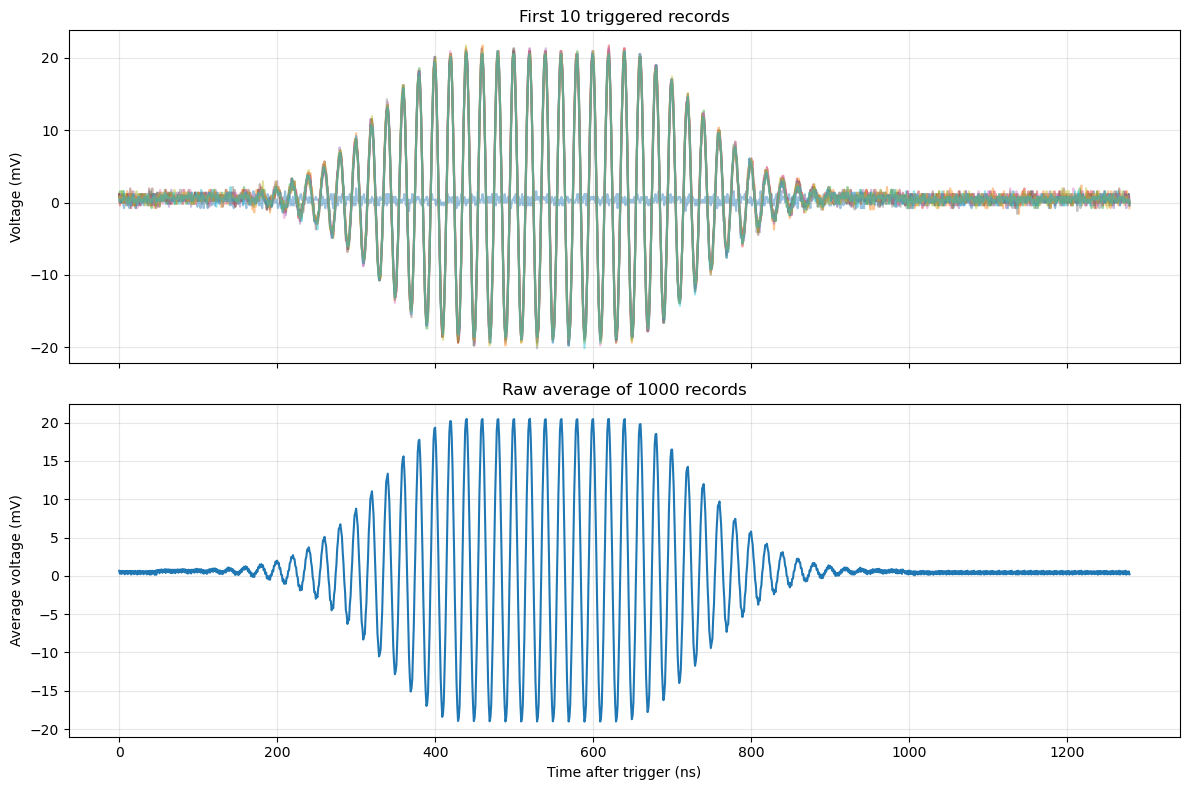

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for shot_index in range(min(10, records_volts.shape[0])):
    axes[0].plot(
        raw_time_ns,
        records_volts[shot_index] * 1e3,
        alpha=0.45,
    )
axes[0].set_title("First 10 triggered records")
axes[0].set_ylabel("Voltage (mV)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(raw_time_ns, np.mean(records_volts, axis=0) * 1e3)
axes[1].set_title(f"Raw average of {records_volts.shape[0]} records")
axes[1].set_xlabel("Time after trigger (ns)")
axes[1].set_ylabel("Average voltage (mV)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Raw average zoom: verify the 50 MHz carrier

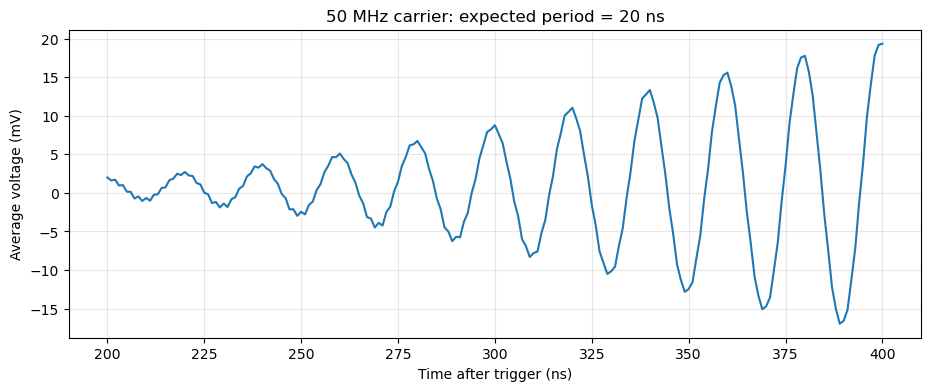

In [12]:
ZOOM_START_NS = 200
ZOOM_STOP_NS = 400
zoom = (raw_time_ns >= ZOOM_START_NS) & (raw_time_ns <= ZOOM_STOP_NS)

plt.figure(figsize=(11, 4))
plt.plot(raw_time_ns[zoom], np.mean(records_volts, axis=0)[zoom] * 1e3)
plt.xlabel("Time after trigger (ns)")
plt.ylabel("Average voltage (mV)")
plt.title("50 MHz carrier: expected period = 20 ns")
plt.grid(True, alpha=0.3)
plt.show()

## Time-resolved moving-average demodulation

This starts a new acquisition. The returned time axis begins at zero and
corresponds to the valid moving-average output.

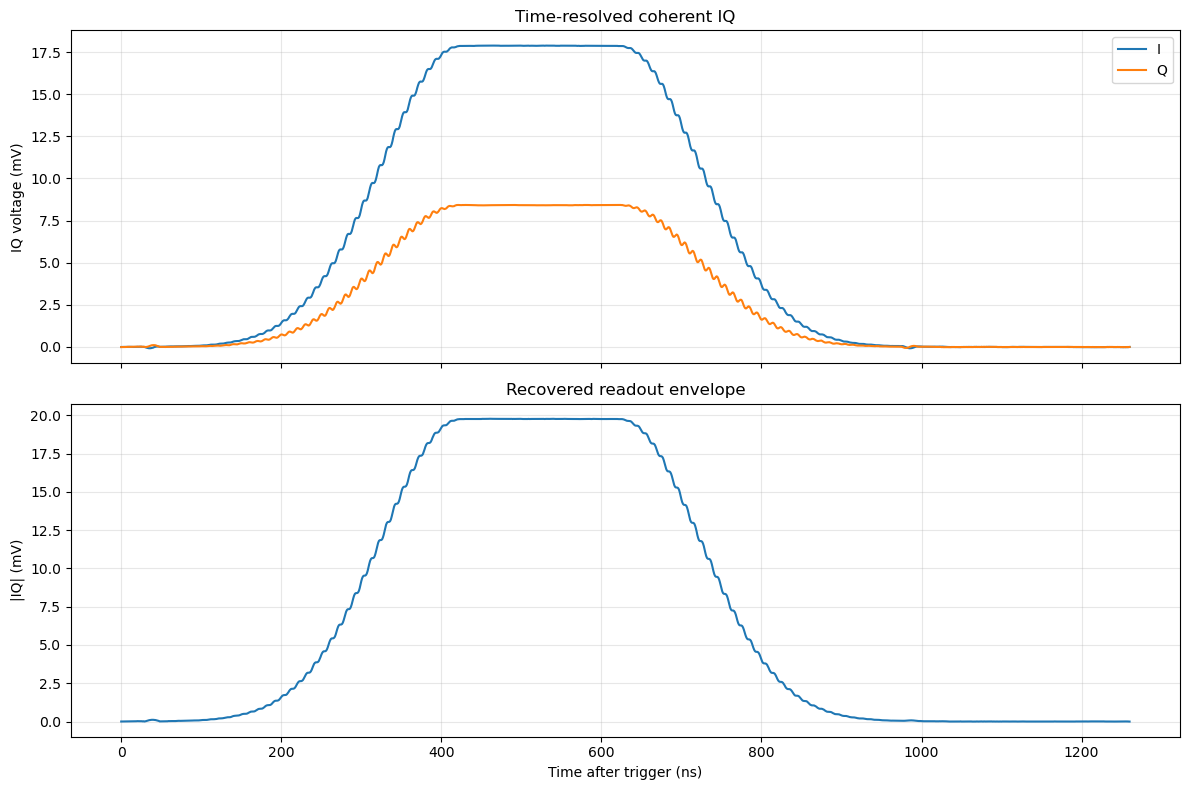

In [15]:
demod_time_s, average_iq = experiment.acquire_decimate(NUM_AVERAGES)
demod_time_ns = demod_time_s * 1e9
shot_iq_filtered = experiment.last_shot_iq

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(demod_time_ns, average_iq.real * 1e3, label="I")
axes[0].plot(demod_time_ns, average_iq.imag * 1e3, label="Q")
axes[0].set_ylabel("IQ voltage (mV)")
axes[0].set_title("Time-resolved coherent IQ")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(demod_time_ns, np.abs(average_iq) * 1e3)
axes[1].set_xlabel("Time after trigger (ns)")
axes[1].set_ylabel("|IQ| (mV)")
axes[1].set_title("Recovered readout envelope")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Individual-shot jitter check

The first record after starting the AWG can occasionally be a startup or
missed-trigger record. Detect those records from their pulse height, report
them explicitly, and exclude them from the timing statistics. Jitter is
measured at the rising-edge half-height crossing of each valid shot.

Valid shots: 999/1000; rejected indices: [0]
Rising edge: mean=308.639 ns, jitter std=0.659 ns, peak-to-peak=5.184 ns


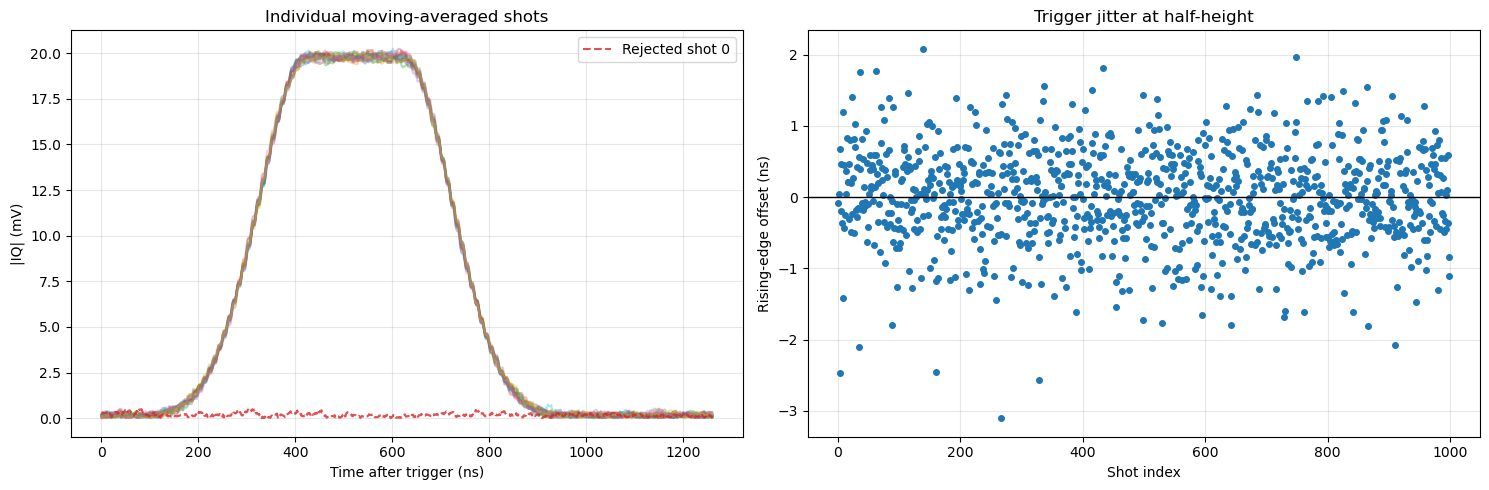

In [16]:
JITTER_SHOTS_TO_PLOT = 20
VALID_SHOT_FRACTION = 0.5

shot_magnitude_mv = np.abs(shot_iq_filtered) * 1e3
shot_baseline_mv = np.median(
    shot_magnitude_mv[:, : max(1, shot_magnitude_mv.shape[1] // 10)],
    axis=1,
)
shot_peak_mv = np.percentile(shot_magnitude_mv, 95, axis=1)
shot_height_mv = shot_peak_mv - shot_baseline_mv
reference_height_mv = np.median(shot_height_mv)
valid_shots = shot_height_mv >= VALID_SHOT_FRACTION * reference_height_mv


def rising_half_height_time_ns(trace_mv, baseline_mv, height_mv):
    threshold_mv = baseline_mv + 0.5 * height_mv
    above = np.flatnonzero(trace_mv >= threshold_mv)
    if above.size == 0 or above[0] == 0:
        return np.nan
    right = above[0]
    left = right - 1
    y0, y1 = trace_mv[left], trace_mv[right]
    if y1 == y0:
        return demod_time_ns[right]
    fraction = (threshold_mv - y0) / (y1 - y0)
    return demod_time_ns[left] + fraction * (
        demod_time_ns[right] - demod_time_ns[left]
    )


rising_edge_ns = np.full(shot_magnitude_mv.shape[0], np.nan)
for shot_index in np.flatnonzero(valid_shots):
    rising_edge_ns[shot_index] = rising_half_height_time_ns(
        shot_magnitude_mv[shot_index],
        shot_baseline_mv[shot_index],
        shot_height_mv[shot_index],
    )

timed_shots = valid_shots & np.isfinite(rising_edge_ns)
invalid_indices = np.flatnonzero(~valid_shots)
print(
    f"Valid shots: {np.count_nonzero(valid_shots)}/{valid_shots.size}; "
    f"rejected indices: {invalid_indices.tolist()}"
)
if np.any(timed_shots):
    print(
        f"Rising edge: mean={np.mean(rising_edge_ns[timed_shots]):.3f} ns, "
        f"jitter std={np.std(rising_edge_ns[timed_shots]):.3f} ns, "
        f"peak-to-peak={np.ptp(rising_edge_ns[timed_shots]):.3f} ns"
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_indices = np.arange(
    min(JITTER_SHOTS_TO_PLOT, shot_magnitude_mv.shape[0])
)
for shot_index in plot_indices[valid_shots[plot_indices]]:
    axes[0].plot(
        demod_time_ns,
        shot_magnitude_mv[shot_index],
        alpha=0.35,
    )
for shot_index in plot_indices[~valid_shots[plot_indices]]:
    axes[0].plot(
        demod_time_ns,
        shot_magnitude_mv[shot_index],
        color="tab:red",
        linestyle="--",
        alpha=0.8,
        label=f"Rejected shot {shot_index}",
    )
axes[0].set_xlabel("Time after trigger (ns)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].set_title("Individual moving-averaged shots")
axes[0].grid(True, alpha=0.3)
if np.any(~valid_shots[plot_indices]):
    axes[0].legend()

if np.any(timed_shots):
    edge_offset_ns = rising_edge_ns[timed_shots] - np.mean(
        rising_edge_ns[timed_shots]
    )
    axes[1].plot(
        np.flatnonzero(timed_shots),
        edge_offset_ns,
        "o",
        markersize=4,
    )
    axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_xlabel("Shot index")
axes[1].set_ylabel("Rising-edge offset (ns)")
axes[1].set_title("Trigger jitter at half-height")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## AWG phase sweep

Each point uploads a waveform with a different carrier phase and performs a
new integrated acquisition. With coherent clocks, the points should rotate
around the IQ plane with approximately constant radius.

In [17]:
PHASE_COUNT = 32
PHASE_AVERAGES = 100

phases = np.linspace(0, 2 * np.pi, PHASE_COUNT, endpoint=False)
phase_points = []
phase_traces = []


def moving_average_rows(values, window_samples):
    padded = np.pad(values, ((0, 0), (1, 0)), mode="constant")
    cumulative = np.cumsum(padded, axis=1)
    return (
        cumulative[:, window_samples:]
        - cumulative[:, :-window_samples]
    ) / window_samples

for phase in phases:
    phase_deg = np.rad2deg(phase)
    upload_readout(
        phase_radians=phase,
        name=f"phase_{phase_deg:06.2f}_deg",
    )
    phase_iq, phase_baseband = experiment.acquire(PHASE_AVERAGES)
    phase_points.append(phase_iq)
    phase_filtered = moving_average_rows(
        phase_baseband,
        experiment.moving_average_samples,
    )
    phase_traces.append(np.mean(phase_filtered, axis=0))
    print(
        f"{phase_deg:7.2f} deg: "
        f"I={phase_iq.real * 1e3:9.4f} mV, "
        f"Q={phase_iq.imag * 1e3:9.4f} mV"
    )

phase_points = np.asarray(phase_points)
phase_traces = np.asarray(phase_traces)

   0.00 deg: I=   8.3254 mV, Q=   2.8032 mV
  11.25 deg: I=   7.0151 mV, Q=   5.2854 mV
  22.50 deg: I=   6.9083 mV, Q=   5.4225 mV
  33.75 deg: I=   4.8800 mV, Q=   7.2961 mV
  45.00 deg: I=   3.3650 mV, Q=   8.1128 mV
  56.25 deg: I=   1.1700 mV, Q=   8.7018 mV
  67.50 deg: I=   1.6723 mV, Q=   8.6192 mV
  78.75 deg: I=  -1.7311 mV, Q=   8.6079 mV
  90.00 deg: I=  -1.8090 mV, Q=   8.5873 mV
 101.25 deg: I=  -4.8374 mV, Q=   7.3289 mV
 112.50 deg: I=  -6.1591 mV, Q=   6.2570 mV
 123.75 deg: I=  -7.5838 mV, Q=   4.4262 mV
 135.00 deg: I=  -8.0920 mV, Q=   3.3938 mV
 146.25 deg: I=  -8.2910 mV, Q=   2.8655 mV
 157.50 deg: I=  -8.7123 mV, Q=   1.0602 mV
 168.75 deg: I=  -8.7561 mV, Q=  -0.5973 mV
 180.00 deg: I=  -8.5931 mV, Q=  -1.7782 mV
 191.25 deg: I=  -7.5843 mV, Q=  -4.4082 mV
 202.50 deg: I=  -7.3039 mV, Q=  -4.8669 mV
 213.75 deg: I=  -4.4400 mV, Q=  -7.5830 mV
 225.00 deg: I=  -4.4184 mV, Q=  -7.5893 mV
 236.25 deg: I=  -3.2410 mV, Q=  -8.1721 mV
 247.50 deg: I=  -1.6944 mV, Q= 

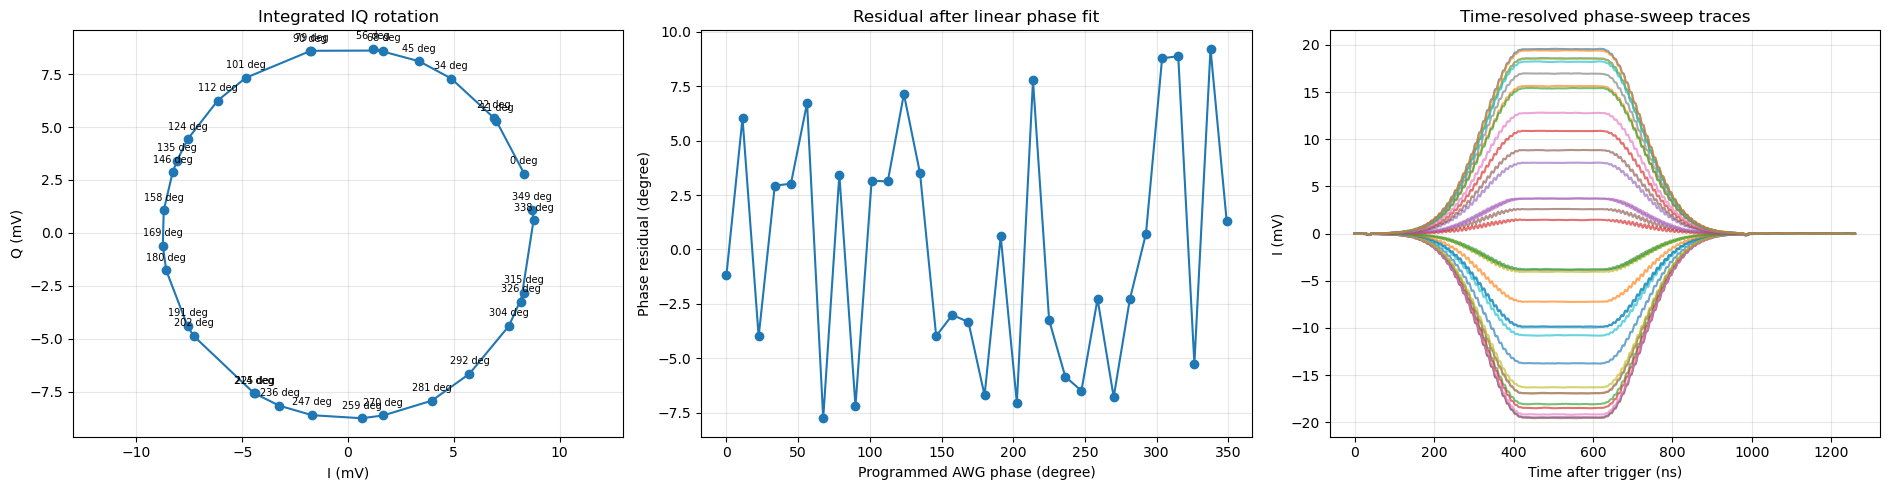

Measured phase slope: 0.992193
Fixed phase offset: 19.802 deg
Maximum phase residual: 9.223 deg
Radius variation: 0.181%


In [18]:
measured_angles = np.unwrap(np.angle(phase_points))
phase_slope, phase_offset = np.polyfit(phases, measured_angles, 1)
phase_fit = phase_slope * phases + phase_offset
phase_residual_deg = np.rad2deg(measured_angles - phase_fit)
radius_mv = np.abs(phase_points) * 1e3
phase_trace_time_ns = (
    np.arange(phase_traces.shape[1])
    / experiment.alazar_sample_rate_hz
    * 1e9
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].plot(
    phase_points.real * 1e3,
    phase_points.imag * 1e3,
    "o-",
)
for phase, point in zip(phases, phase_points):
    axes[0].annotate(
        f"{np.rad2deg(phase):.0f} deg",
        (point.real * 1e3, point.imag * 1e3),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=7,
    )
axes[0].set_xlabel("I (mV)")
axes[0].set_ylabel("Q (mV)")
axes[0].set_title("Integrated IQ rotation")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.rad2deg(phases), phase_residual_deg, "o-")
axes[1].set_xlabel("Programmed AWG phase (degree)")
axes[1].set_ylabel("Phase residual (degree)")
axes[1].set_title("Residual after linear phase fit")
axes[1].grid(True, alpha=0.3)

for phase, trace in zip(phases, phase_traces):
    axes[2].plot(
        phase_trace_time_ns,
        trace.real * 1e3,
        alpha=0.65,
        label=f"{np.rad2deg(phase):.0f} deg",
    )
axes[2].set_xlabel("Time after trigger (ns)")
axes[2].set_ylabel("I (mV)")
axes[2].set_title("Time-resolved phase-sweep traces")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Measured phase slope: {phase_slope:.6f}")
print(f"Fixed phase offset: {np.rad2deg(phase_offset):.3f} deg")
print(f"Maximum phase residual: {np.max(np.abs(phase_residual_deg)):.3f} deg")
print(f"Radius variation: {np.std(radius_mv) / np.mean(radius_mv) * 100:.3f}%")

## Single-shot IQ: 0 and 180 degree calibration

These are hardware single shots, not averaged points. `last_shot_iq` contains
one integrated complex value for every trigger record.

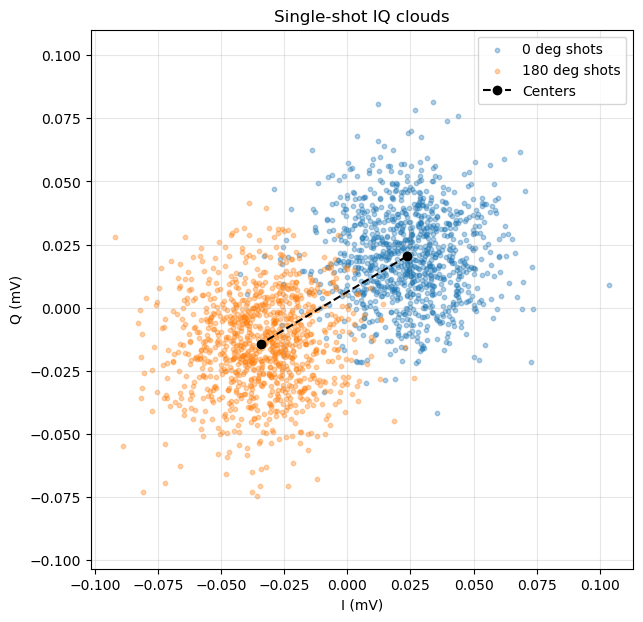

In [20]:
SINGLE_SHOT_AVERAGES = 1000
SINGLE_SHOT_PEAK_VOLTS = 0.00005

upload_readout(
    phase_radians=0.0,
    peak_volts=SINGLE_SHOT_PEAK_VOLTS,
    name="single_shot_0_deg",
)
center_0, downconverted_0 = experiment.acquire(SINGLE_SHOT_AVERAGES)
shots_0 = experiment.last_shot_iq.copy()

upload_readout(
    phase_radians=np.pi,
    peak_volts=SINGLE_SHOT_PEAK_VOLTS,
    name="single_shot_180_deg",
)
center_180, downconverted_180 = experiment.acquire(SINGLE_SHOT_AVERAGES)
shots_180 = experiment.last_shot_iq.copy()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    shots_0.real * 1e3,
    shots_0.imag * 1e3,
    s=10,
    alpha=0.35,
    label="0 deg shots",
)
ax.scatter(
    shots_180.real * 1e3,
    shots_180.imag * 1e3,
    s=10,
    alpha=0.35,
    label="180 deg shots",
)
ax.plot(
    [center_0.real * 1e3, center_180.real * 1e3],
    [center_0.imag * 1e3, center_180.imag * 1e3],
    "ko--",
    label="Centers",
)
ax.set_xlabel("I (mV)")
ax.set_ylabel("Q (mV)")
ax.set_title("Single-shot IQ clouds")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Increasing-integration trajectory

At time index `n`, each trajectory point is the mean of samples from trigger
time zero through `n`. Therefore the integration window grows one ADC cycle at
a time. Every individual shot is retained.

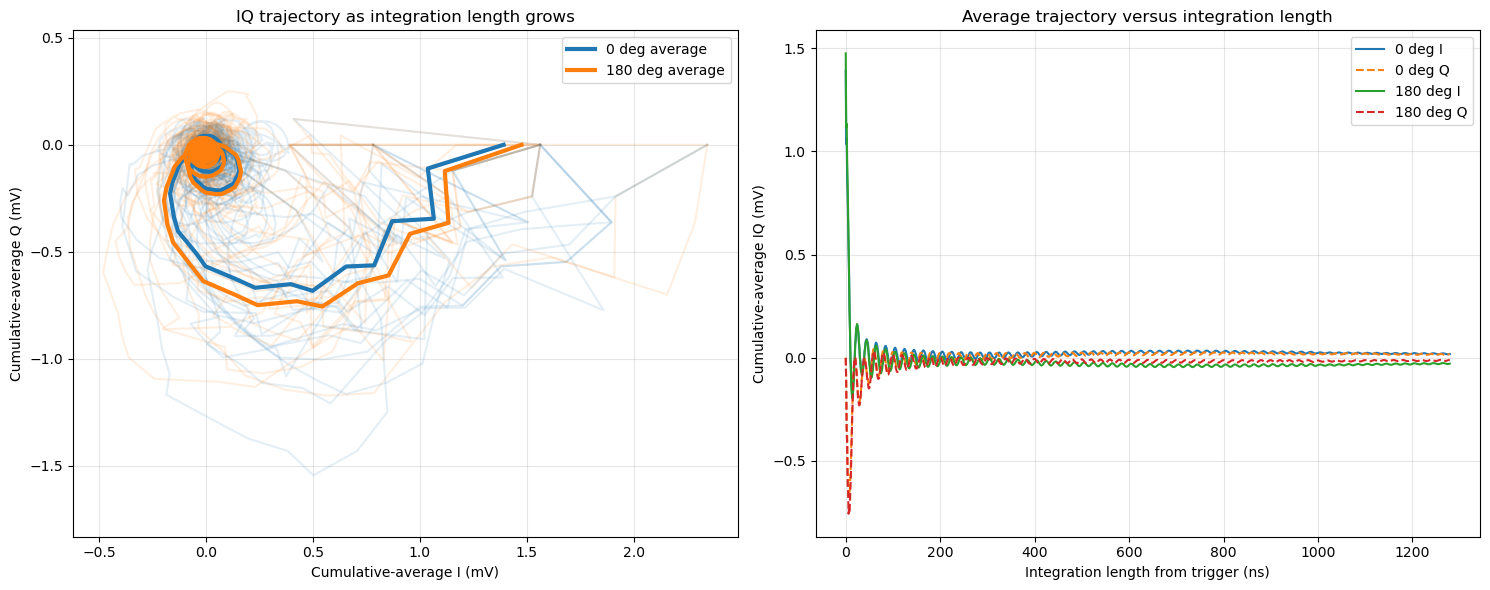

In [21]:
def cumulative_average_iq(downconverted):
    sample_counts = np.arange(1, downconverted.shape[1] + 1)
    return np.cumsum(downconverted, axis=1) / sample_counts


trajectory_0 = cumulative_average_iq(downconverted_0)
trajectory_180 = cumulative_average_iq(downconverted_180)
trajectory_time_ns = (
    np.arange(downconverted_0.shape[1])
    / experiment.alazar_sample_rate_hz
    * 1e9
)

TRAJECTORIES_TO_PLOT = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for shot_index in range(min(TRAJECTORIES_TO_PLOT, trajectory_0.shape[0])):
    axes[0].plot(
        trajectory_0[shot_index].real * 1e3,
        trajectory_0[shot_index].imag * 1e3,
        color="tab:blue",
        alpha=0.12,
    )
    axes[0].plot(
        trajectory_180[shot_index].real * 1e3,
        trajectory_180[shot_index].imag * 1e3,
        color="tab:orange",
        alpha=0.12,
    )

average_trajectory_0 = np.mean(trajectory_0, axis=0)
average_trajectory_180 = np.mean(trajectory_180, axis=0)
axes[0].plot(
    average_trajectory_0.real * 1e3,
    average_trajectory_0.imag * 1e3,
    color="tab:blue",
    linewidth=3,
    label="0 deg average",
)
axes[0].plot(
    average_trajectory_180.real * 1e3,
    average_trajectory_180.imag * 1e3,
    color="tab:orange",
    linewidth=3,
    label="180 deg average",
)
axes[0].set_xlabel("Cumulative-average I (mV)")
axes[0].set_ylabel("Cumulative-average Q (mV)")
axes[0].set_title("IQ trajectory as integration length grows")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(
    trajectory_time_ns,
    average_trajectory_0.real * 1e3,
    label="0 deg I",
)
axes[1].plot(
    trajectory_time_ns,
    average_trajectory_0.imag * 1e3,
    "--",
    label="0 deg Q",
)
axes[1].plot(
    trajectory_time_ns,
    average_trajectory_180.real * 1e3,
    label="180 deg I",
)
axes[1].plot(
    trajectory_time_ns,
    average_trajectory_180.imag * 1e3,
    "--",
    label="180 deg Q",
)
axes[1].set_xlabel("Integration length from trigger (ns)")
axes[1].set_ylabel("Cumulative-average IQ (mV)")
axes[1].set_title("Average trajectory versus integration length")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Optional save

In [ ]:
np.savez(
    "awg_alazar_unified_capture.npz",
    raw_codes=raw_codes,
    records_volts=records_volts,
    downconverted_iq=downconverted_iq,
    average_iq=average_iq,
    phase_radians=phases,
    phase_points=phase_points,
    shots_0=shots_0,
    shots_180=shots_180,
    trajectory_0=trajectory_0,
    trajectory_180=trajectory_180,
)
print("Saved awg_alazar_unified_capture.npz")

## Close hardware sessions

In [ ]:
experiment.close()
print("AWG VISA session closed")